# Telco Customer Churn — Complete ML Project

### Goal
Build a clean, leakage-safe customer churn classification project from the original notebook, first using **basic preprocessing**, then improving the models with **feature engineering, class-imbalance handling, cross-validation, and hyperparameter tuning**.

### What this notebook fixes from the original project
- Keeps preprocessing inside `Pipeline` / `ColumnTransformer` so the test set is never used to fit preprocessing.
- Uses **one-hot encoding** for nominal categorical variables such as `Contract` instead of assigning artificial numeric order.
- Handles `TotalCharges` explicitly and documents the assumption used for its blank values.
- Avoids double-scaling the same numerical columns.
- Creates engineered features **before the train/test split**, but fits learned preprocessing only on training data.
- Evaluates models with **accuracy, precision, recall, F1, ROC-AUC, PR-AUC, and confusion matrices** rather than accuracy alone.
- Compares **baseline models** against **improved/tuned models**.
- Uses stratified cross-validation and parameter search for tuning.
- Separates descriptive EDA observations from causal claims.




## 1. Imports and configuration

**Why?** Keep all imports and reproducibility settings in one place. `random_state=42` makes the experiments repeatable.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

from scipy.stats import loguniform, randint

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load the dataset

The original notebook uses `Churn_Data.csv`. The code below also accepts the common original filename. If neither file exists, it attempts to download a public copy of the same dataset when internet access is available.

In [ ]:
LOCAL_CANDIDATES = [
    "Churn_Data.csv",
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
]

DATA_URL = (
    "https://raw.githubusercontent.com/SaeidRostami/Customer_Churn/"
    "master/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

DATA_PATH = next((p for p in LOCAL_CANDIDATES if os.path.exists(p)), None)

if DATA_PATH is None:
    try:
        df = pd.read_csv(DATA_URL)
        print("Loaded dataset from public fallback URL.")
    except Exception as e:
        raise FileNotFoundError(
            "Dataset not found. Put Churn_Data.csv or "
            "WA_Fn-UseC_-Telco-Customer-Churn.csv in the working directory."
        ) from e
else:
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded: {DATA_PATH}")

print("Shape:", df.shape)
df.head()

Loaded dataset from public fallback URL.
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Initial data audit

In [ ]:
print(df.info())
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget distribution:")
display(df["Churn"].value_counts())
display(df["Churn"].value_counts(normalize=True).rename("proportion"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Duplicate rows: 0

Target distribution:


,count
Churn,
No,5174
Yes,1869


,proportion
Churn,
No,0.73463
Yes,0.26537


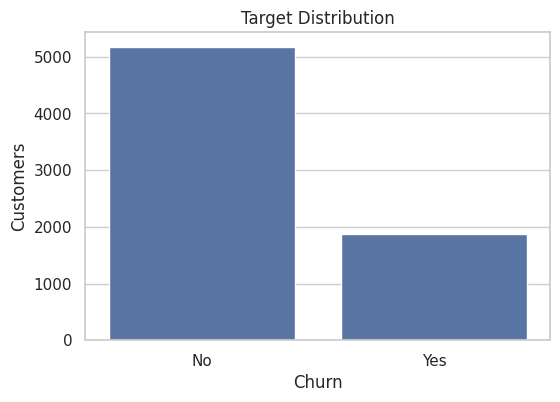

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Target Distribution")
plt.xlabel("Churn")
plt.ylabel("Customers")
plt.show()

### Note on class imbalance

The dataset is imbalanced: there are substantially more non-churners than churners. Therefore, **accuracy alone can be misleading**. Later we will compare precision, recall, F1, ROC-AUC and PR-AUC.

## 4. Correct data cleaning

The original notebook correctly noticed that `TotalCharges` contains blank strings. Converting it with `errors="coerce"` turns those blanks into missing values.

For this dataset, the blank `TotalCharges` records correspond to customers with zero tenure. Because `TotalCharges` represents accumulated charges, using `tenure × MonthlyCharges` gives zero for those records. We document the assumption rather than silently hiding it.

In [ ]:
df = df.copy()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

blank_totalcharges = df["TotalCharges"].isna().sum()
print("TotalCharges values converted to NaN:", blank_totalcharges)

# Document the original rows before imputation.
if blank_totalcharges > 0:
    display(df.loc[df["TotalCharges"].isna(), ["tenure", "MonthlyCharges", "TotalCharges"]])

# Dataset-specific, documented imputation rule.
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["tenure"] * df["MonthlyCharges"]
)

print("Remaining TotalCharges missing values:", df["TotalCharges"].isna().sum())

TotalCharges values converted to NaN: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


Remaining TotalCharges missing values: 0


## 5. EDA — useful relationships, without causal claims

The original notebook explored tenure, MonthlyCharges, TotalCharges, Contract, InternetService and PaymentMethod. Those are retained here, but the written conclusions are phrased as **associations** rather than claims that one variable causes churn.

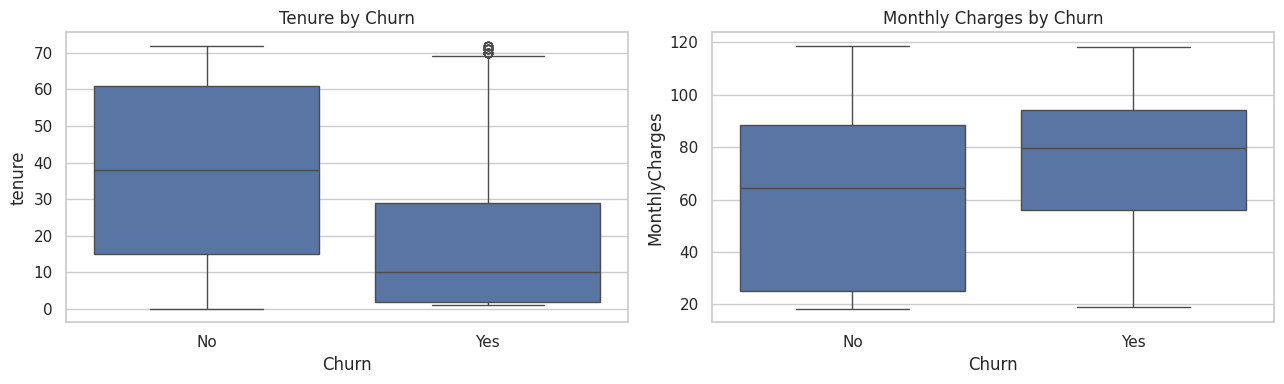

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0])
axes[0].set_title("Tenure by Churn")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Monthly Charges by Churn")

plt.tight_layout()
plt.show()

Churn percentage within each contract type:


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


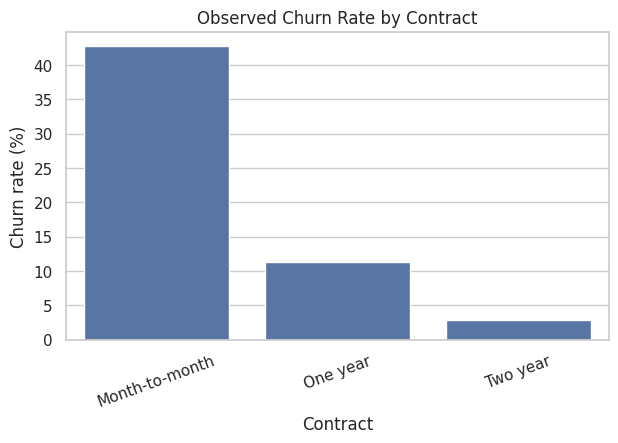

In [ ]:
contract_churn = pd.crosstab(
    df["Contract"], df["Churn"], normalize="index"
) * 100

print("Churn percentage within each contract type:")
display(contract_churn)

plt.figure(figsize=(7,4))
churn_rate = (
    df.assign(churn_flag=(df["Churn"] == "Yes").astype(int))
      .groupby("Contract")["churn_flag"].mean()
      .sort_values(ascending=False) * 100
)
sns.barplot(x=churn_rate.index, y=churn_rate.values)
plt.ylabel("Churn rate (%)")
plt.title("Observed Churn Rate by Contract")
plt.xticks(rotation=20)
plt.show()

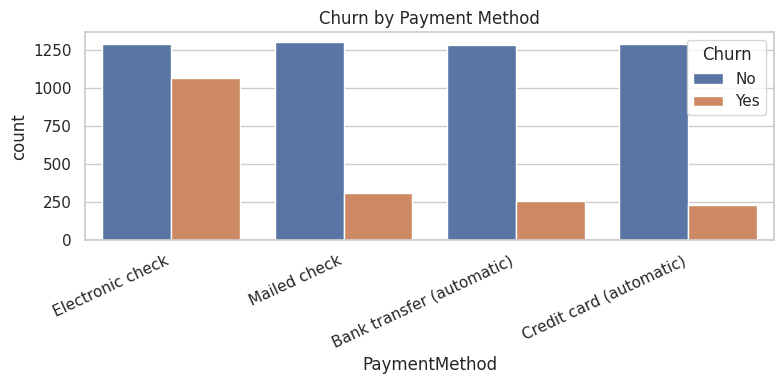

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn by Payment Method")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### EDA interpretation

- Short-tenure customers show a different churn pattern from long-tenure customers.
- Month-to-month contracts have a higher observed churn rate than longer contracts in this dataset.
- Payment method and internet-service categories also show different observed churn rates.
- These are **descriptive associations**. They do not prove that changing a contract or payment method would itself cause churn to fall.

## 6. Feature engineering

The original notebook created `total_services` from OnlineSecurity, OnlineBackup and DeviceProtection. We retain that idea and make it slightly more systematic.

We also create:
- `total_addon_services`: number of optional services adopted.
- `is_month_to_month`: indicator for month-to-month contract.
- `is_new_customer`: indicator for very short tenure (≤ 6 months).
- `avg_monthly_charge_per_tenure`: a deliberately simple ratio; because tenure can be zero, we use `tenure + 1` to avoid division by zero. This is exploratory and is not guaranteed to improve the model.

**Why?** Feature engineering lets the model see business-relevant combinations instead of forcing every relationship to be learned from raw columns alone.

In [ ]:
# Normalize service-related categories before counting them.
service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

for col in service_cols:
    df[col] = df[col].replace("No internet service", "No")

df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")

# Count optional services where Yes=1.
df["total_addon_services"] = (
    df[service_cols].eq("Yes").sum(axis=1)
)

df["is_month_to_month"] = (df["Contract"] == "Month-to-month").astype(int)
df["is_new_customer"] = (df["tenure"] <= 6).astype(int)
df["avg_monthly_charge_per_tenure"] = (
    df["TotalCharges"] / (df["tenure"] + 1)
)

display(df[[
    "tenure", "MonthlyCharges", "TotalCharges",
    "total_addon_services", "is_month_to_month",
    "is_new_customer", "avg_monthly_charge_per_tenure"
]].head())

,tenure,MonthlyCharges,TotalCharges,total_addon_services,is_month_to_month,is_new_customer,avg_monthly_charge_per_tenure
0,1,29.85,29.85,1,1,1,14.925000
1,34,56.95,1889.50,2,0,0,53.985714
2,2,53.85,108.15,2,1,1,36.050000
3,45,42.30,1840.75,3,0,0,40.016304
4,2,70.70,151.65,0,1,1,50.550000


## 7. Define X/y and remove the identifier

`customerID` is an identifier, not a customer-behavior feature. Keeping it could let the model learn meaningless patterns, so it is removed.

In [ ]:
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Train churn rate:", y_train.mean())
print("Test churn rate :", y_test.mean())

X_train: (5634, 23)
X_test : (1409, 23)
Train churn rate: 0.2653532126375577
Test churn rate : 0.2654364797728886


## 8. Basic preprocessing — leakage-safe

This is the **baseline preprocessing** stage.

### Numerical columns
- median imputation
- standardization for scale-sensitive models

### Categorical columns
- most-frequent imputation
- one-hot encoding
- `handle_unknown="ignore"` so unseen test categories do not break the pipeline

### Why not manually encode everything?
Manual encoding in the original notebook made it easy to accidentally impose artificial order, double-scale columns, or fit transformations outside the training set. `ColumnTransformer` keeps the process explicit and safe.

In [ ]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_basic = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_scaled = ColumnTransformer([
    ("num", numeric_scaled, numeric_features),
    ("cat", categorical_basic, categorical_features)
])

# Tree models do not need scaling, so keep a separate tree preprocessor.
numeric_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_tree = ColumnTransformer([
    ("num", numeric_tree, numeric_features),
    ("cat", categorical_basic, categorical_features)
])
X_train.head()

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'total_addon_services', 'is_month_to_month', 'is_new_customer', 'avg_monthly_charge_per_tenure']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,total_addon_services,is_month_to_month,is_new_customer,avg_monthly_charge_per_tenure
3738,Male,0,No,No,35,No,No,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,3,1,0,47.268056
3151,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,1,1,0,71.971875
4860,Male,0,Yes,Yes,13,No,No,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,3,0,0,42.167857
3867,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,4,0,0,70.581481
3810,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,0,1,1,22.275000


# 9. Baseline models

We now test the same core model families used in the original notebook:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. SVM

A Gradient Boosting model is also added as a useful additional nonlinear baseline.

**Important:** These are baseline models. We intentionally do not tune them yet so we can measure whether later changes actually improve performance.

In [ ]:
baseline_models = {
    "Logistic Regression": Pipeline([
        ("preprocess", preprocessor_scaled),
        ("model", LogisticRegression(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            max_iter=2000
        ))
    ]),
    "Decision Tree": Pipeline([
        ("preprocess", preprocessor_tree),
        ("model", DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),
    "Random Forest": Pipeline([
        ("preprocess", preprocessor_tree),
        ("model", RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    "SVM": Pipeline([
        ("preprocess", preprocessor_scaled),
        ("model", SVC(
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocess", preprocessor_tree),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ])
}

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    }
    return model, pred, prob, result

baseline_results = []
baseline_fitted = {}

for name, model in baseline_models.items():
    fitted, pred, prob, result = evaluate_model(
        model, X_train, y_train, X_test, y_test, name
    )
    baseline_fitted[name] = (fitted, pred, prob)
    baseline_results.append(result)

baseline_results_df = pd.DataFrame(baseline_results).sort_values("F1", ascending=False)
display(baseline_results_df)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
3,SVM,0.765082,0.540643,0.764706,0.633444,0.822049,0.583825
0,Logistic Regression,0.738822,0.505119,0.791444,0.616667,0.846986,0.661511
4,Gradient Boosting,0.801278,0.660959,0.516043,0.579580,0.843806,0.659111
2,Random Forest,0.780696,0.614841,0.465241,0.529680,0.821371,0.608098
1,Decision Tree,0.731725,0.494595,0.489305,0.491935,0.654787,0.378880


## 10. Baseline visualization

The chart below makes it easier to see how the models trade off different metrics. There is no single universally correct metric; for churn, recall and PR-AUC are particularly useful when the goal is to identify more potential churners.

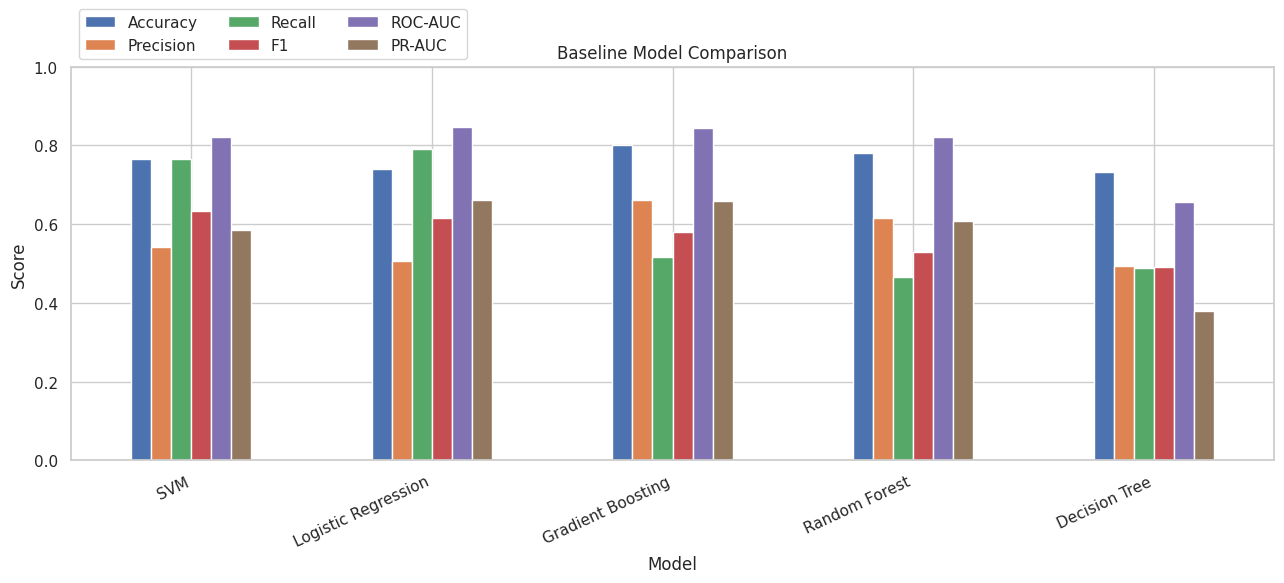

In [ ]:
plot_df = baseline_results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]]
plot_df.plot(kind="bar", figsize=(13, 6))
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Baseline Model Comparison")
plt.xticks(rotation=25, ha="right")
plt.legend(loc="lower left", bbox_to_anchor=(0, 1), ncol=3)
plt.tight_layout()
plt.show()

## 11. Confusion matrices and classification reports

A confusion matrix separates:
- **TN:** correctly predicted non-churners
- **FP:** customers predicted to churn but who did not
- **FN:** churners the model missed
- **TP:** correctly identified churners

For a retention use case, the FN count deserves special attention because these are actual churners that the model failed to identify.

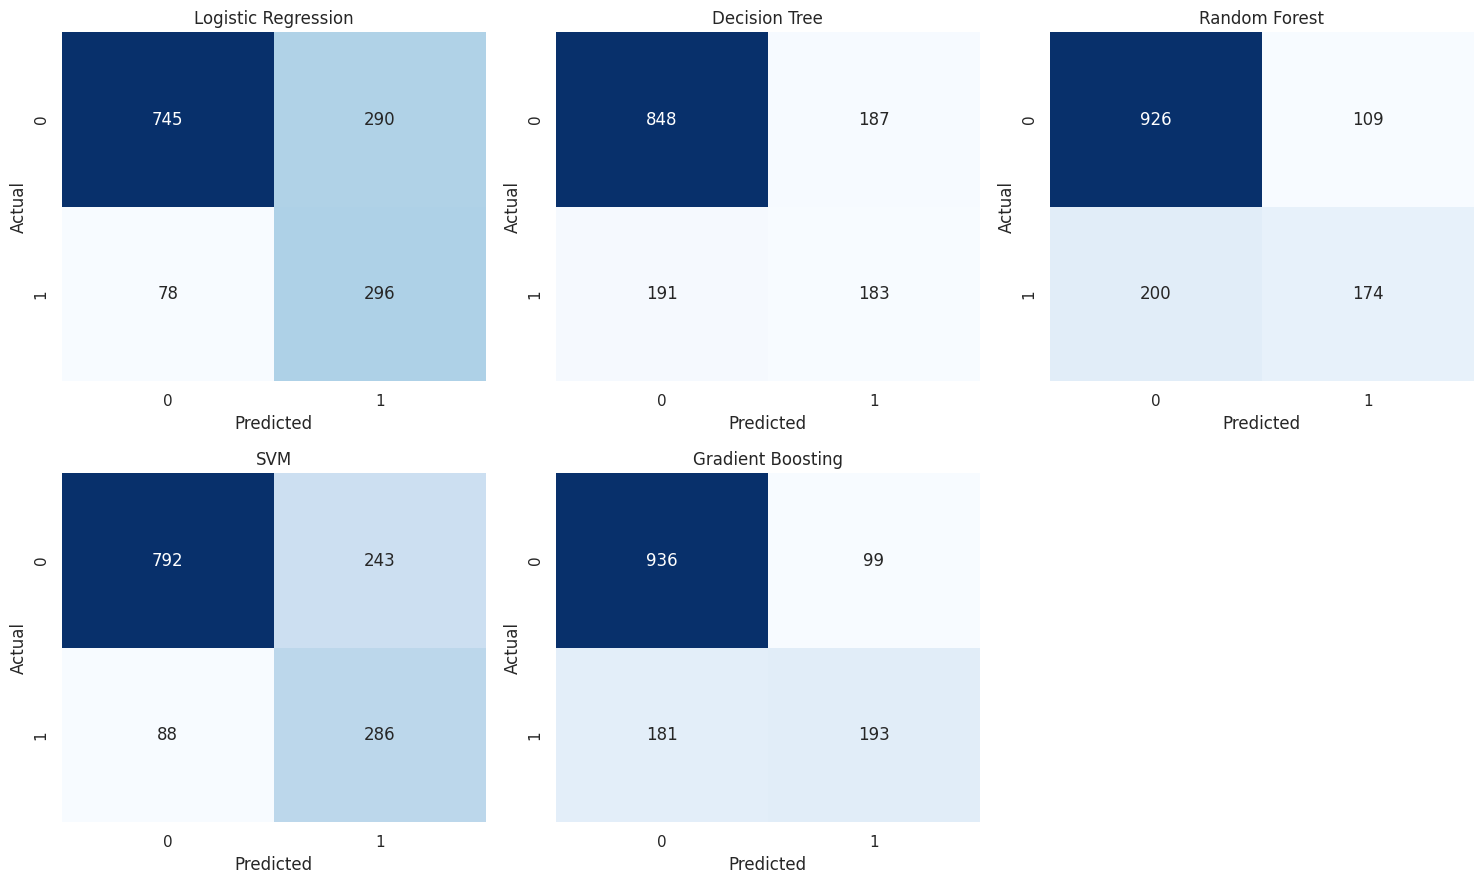


Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Decision Tree
              precision    recall  f1-score   support

    No Churn       0.82      0.82      0.82      1035
       Churn       0.49      0.49      0.49       374

    accuracy                           0.73      1409
   macro avg       0.66      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409


Random Forest
              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.86      1035
       Churn       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, (name, (_, pred, _)) in zip(axes, baseline_fitted.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

for name, (model, pred, prob) in baseline_fitted.items():
    print(f"\n{'='*70}\n{name}\n{'='*70}")
    print(classification_report(y_test, pred, target_names=["No Churn", "Churn"], zero_division=0))

# 12. ROC and Precision-Recall curves

ROC-AUC summarizes ranking ability across classification thresholds. PR-AUC is especially informative when the positive class is less common because it focuses on the precision/recall trade-off for churners.

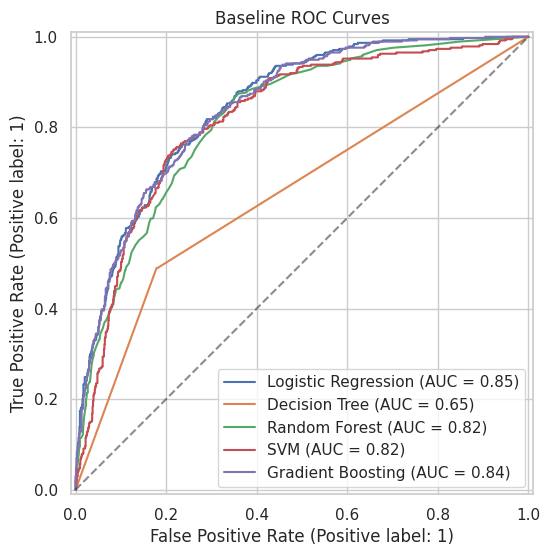

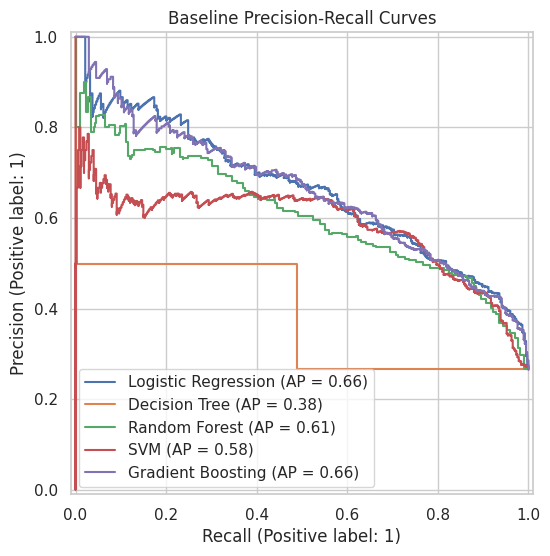

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, (_, _, prob) in baseline_fitted.items():
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_title("Baseline ROC Curves")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for name, (_, _, prob) in baseline_fitted.items():
    PrecisionRecallDisplay.from_predictions(y_test, prob, name=name, ax=ax)
ax.set_title("Baseline Precision-Recall Curves")
plt.show()

# 13. Improvement 1 — better feature engineering

The baseline already includes the engineered features so that the comparison is clean. To explicitly measure the effect of feature engineering, we create a **raw-feature baseline dataset** and compare it with the engineered dataset using the same model and preprocessing strategy.

This answers an important ML question:

> Did my feature engineering actually help, or did I just make the notebook more complicated?

In [ ]:
# Recreate the raw feature set from the cleaned dataset before engineered columns.
engineered_cols = [
    "total_addon_services",
    "is_month_to_month",
    "is_new_customer",
    "avg_monthly_charge_per_tenure"
]

X_engineered = df.drop(columns=["Churn", "customerID"])
X_raw = X_engineered.drop(columns=engineered_cols)

y_all = df["Churn"].map({"No": 0, "Yes": 1})

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_raw, y_all, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=y_all
)

Xe_train, Xe_test, ye_train, ye_test = train_test_split(
    X_engineered, y_all, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=y_all
)

# Same model; separate preprocessors are constructed from each training split.
def make_logistic_pipeline(X_train_local):
    num = X_train_local.select_dtypes(include=["number"]).columns.tolist()
    cat = X_train_local.select_dtypes(exclude=["number"]).columns.tolist()
    prep = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat)
    ])
    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(
            class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE
        ))
    ])

raw_lr = make_logistic_pipeline(Xr_train)
eng_lr = make_logistic_pipeline(Xe_train)

raw_lr.fit(Xr_train, yr_train)
eng_lr.fit(Xe_train, ye_train)

raw_pred = raw_lr.predict(Xr_test)
eng_pred = eng_lr.predict(Xe_test)
raw_prob = raw_lr.predict_proba(Xr_test)[:,1]
eng_prob = eng_lr.predict_proba(Xe_test)[:,1]

feature_engineering_results = pd.DataFrame([
    {
        "Version": "Raw features",
        "Accuracy": accuracy_score(yr_test, raw_pred),
        "Precision": precision_score(yr_test, raw_pred),
        "Recall": recall_score(yr_test, raw_pred),
        "F1": f1_score(yr_test, raw_pred),
        "ROC-AUC": roc_auc_score(yr_test, raw_prob),
        "PR-AUC": average_precision_score(yr_test, raw_prob)
    },
    {
        "Version": "Engineered features",
        "Accuracy": accuracy_score(ye_test, eng_pred),
        "Precision": precision_score(ye_test, eng_pred),
        "Recall": recall_score(ye_test, eng_pred),
        "F1": f1_score(ye_test, eng_pred),
        "ROC-AUC": roc_auc_score(ye_test, eng_prob),
        "PR-AUC": average_precision_score(ye_test, eng_prob)
    }
])

display(feature_engineering_results)

,Version,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Raw features,0.738822,0.505155,0.786096,0.615063,0.841685,0.633763
1,Engineered features,0.738822,0.505119,0.791444,0.616667,0.846986,0.661511


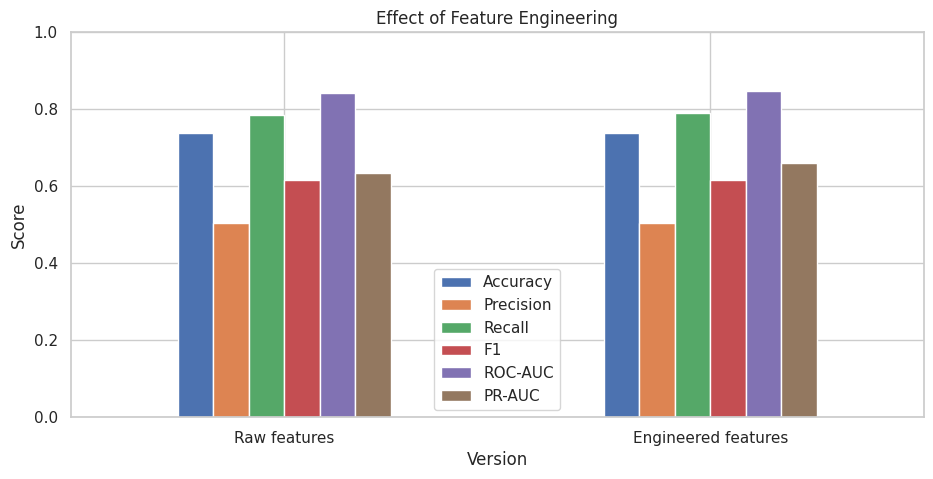

In [ ]:
feature_engineering_results.set_index("Version")[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
].plot(kind="bar", figsize=(11, 5))
plt.ylim(0, 1)
plt.title("Effect of Feature Engineering")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

# 14. Improvement 2 — hyperparameter tuning

Now we tune the models rather than accepting sklearn defaults.

### Why tune?
A model's algorithm is only part of its behavior. Hyperparameters such as:
- Logistic Regression `C`
- Decision Tree `max_depth`, `min_samples_leaf`
- Random Forest `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`
- SVM `C` and `gamma`

control complexity and the bias/variance trade-off.

We use **5-fold stratified cross-validation** so the test set remains untouched during model selection.

## 14.1 Tune Logistic Regression

`C` is the inverse of regularization strength:
- smaller `C` → stronger regularization
- larger `C` → weaker regularization

In [ ]:
logistic_pipe = baseline_models["Logistic Regression"]

logistic_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

logistic_search = GridSearchCV(
    logistic_pipe,
    logistic_grid,
    scoring="f1",
    cv=CV,
    n_jobs=-1,
    return_train_score=True
)

logistic_search.fit(X_train, y_train)
print("Best parameters:", logistic_search.best_params_)
print("Best CV F1:", logistic_search.best_score_)

Best parameters: {'model__C': 10, 'model__solver': 'lbfgs'}
Best CV F1: 0.6342992291374945


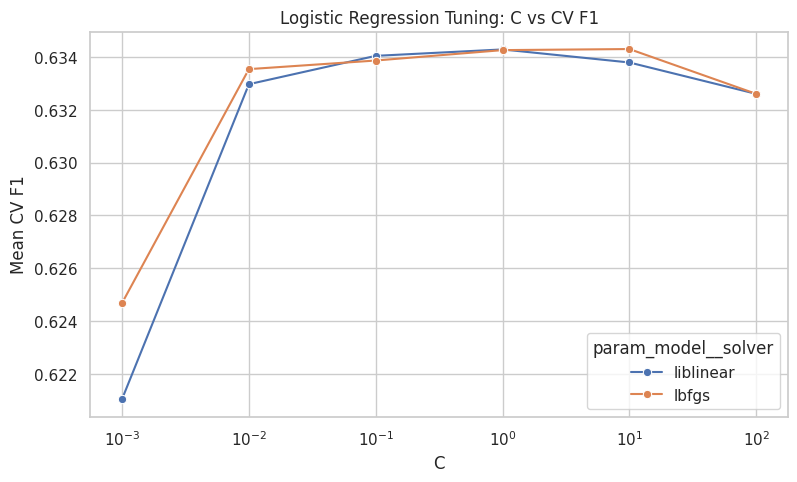

In [ ]:
logistic_cv = pd.DataFrame(logistic_search.cv_results_)

plt.figure(figsize=(9,5))
sns.lineplot(
    data=logistic_cv,
    x="param_model__C",
    y="mean_test_score",
    marker="o",
    hue="param_model__solver"
)
plt.xscale("log")
plt.ylabel("Mean CV F1")
plt.xlabel("C")
plt.title("Logistic Regression Tuning: C vs CV F1")
plt.show()

## 14.2 Tune Decision Tree

Decision trees can easily overfit. `max_depth` and `min_samples_leaf` control how complex the tree is allowed to become.

In [ ]:
dt_pipe = baseline_models["Decision Tree"]

dt_grid = {
    "model__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "model__min_samples_leaf": [1, 2, 5, 10, 20, 30],
    "model__criterion": ["gini", "entropy", "log_loss"]
}

dt_search = RandomizedSearchCV(
    dt_pipe,
    dt_grid,
    n_iter=40,
    scoring="f1",
    cv=CV,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True
)

dt_search.fit(X_train, y_train)
print("Best parameters:", dt_search.best_params_)
print("Best CV F1:", dt_search.best_score_)

Best parameters: {'model__min_samples_leaf': 5, 'model__max_depth': 3, 'model__criterion': 'entropy'}
Best CV F1: 0.6193539721212385


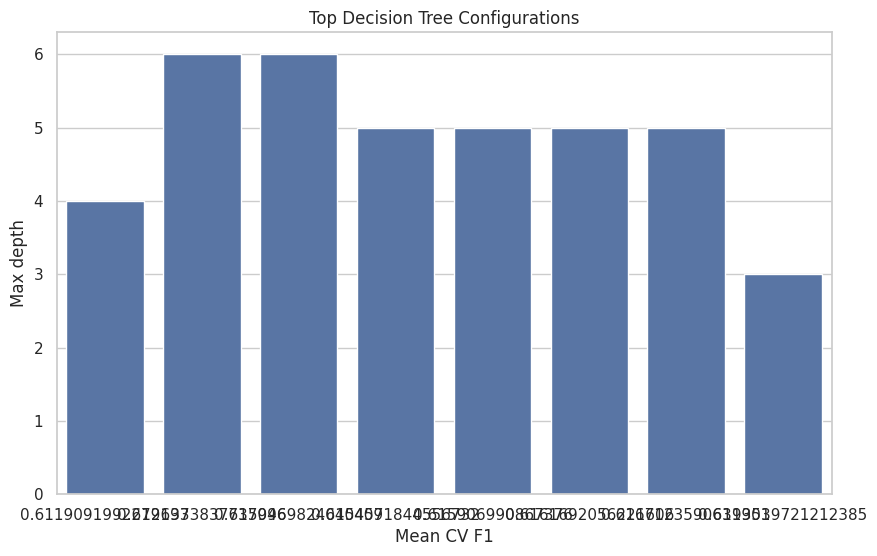

In [ ]:
dt_cv = pd.DataFrame(dt_search.cv_results_).sort_values("mean_test_score", ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(data=dt_cv, x="mean_test_score", y="param_model__max_depth")
plt.xlabel("Mean CV F1")
plt.ylabel("Max depth")
plt.title("Top Decision Tree Configurations")
plt.show()

## 14.3 Tune Random Forest

Random Forest has several useful complexity controls. We use randomized search because the parameter space is larger than the small grid used for Logistic Regression.

In [ ]:
rf_pipe = baseline_models["Random Forest"]

rf_grid = {
    "model__n_estimators": randint(100, 500),
    "model__max_depth": [None, 4, 6, 8, 10, 12, 16],
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf": randint(1, 10),
    "model__max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    rf_grid,
    n_iter=50,
    scoring="f1",
    cv=CV,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True
)

rf_search.fit(X_train, y_train)
print("Best parameters:", rf_search.best_params_)
print("Best CV F1:", rf_search.best_score_)

Best parameters: {'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 6, 'model__n_estimators': 330}
Best CV F1: 0.6404364513859874


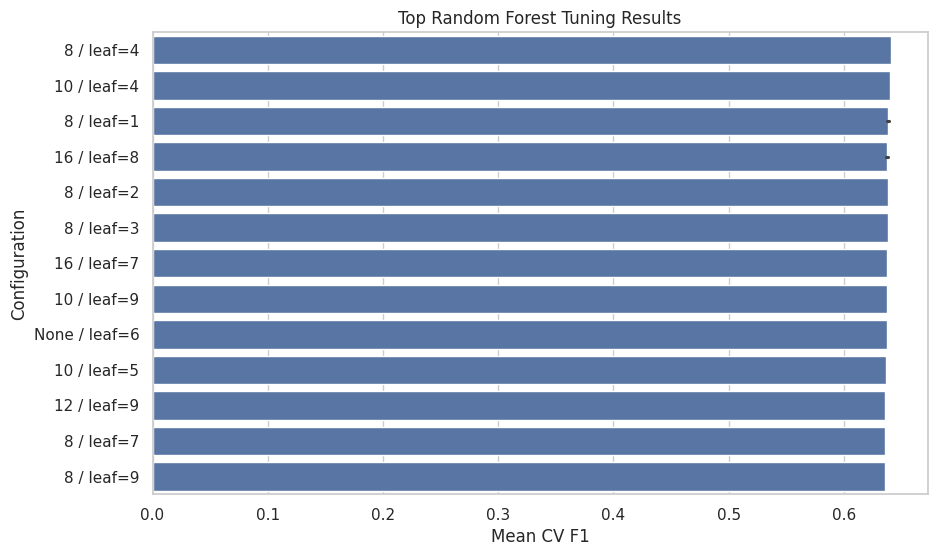

In [ ]:
rf_cv = pd.DataFrame(rf_search.cv_results_).sort_values("mean_test_score", ascending=False).head(15)
rf_cv = rf_cv.copy()
rf_cv["config"] = [f"{d} / leaf={l}" for d, l in zip(
    rf_cv["param_model__max_depth"], rf_cv["param_model__min_samples_leaf"]
)]

plt.figure(figsize=(10,6))
sns.barplot(data=rf_cv, x="mean_test_score", y="config")
plt.xlabel("Mean CV F1")
plt.ylabel("Configuration")
plt.title("Top Random Forest Tuning Results")
plt.show()

## 14.4 Tune SVM

For an RBF SVM:
- `C` controls the penalty for classification errors.
- `gamma` controls how local/influential individual training examples are.

Both can strongly affect overfitting, so we search them on logarithmic scales.

In [ ]:
svm_pipe = baseline_models["SVM"]

svm_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.001, 0.01, 0.1, 1],
    "model__kernel": ["rbf"]
}

svm_search = GridSearchCV(
    svm_pipe,
    svm_grid,
    scoring="f1",
    cv=CV,
    n_jobs=-1,
    return_train_score=True
)

svm_search.fit(X_train, y_train)
print("Best parameters:", svm_search.best_params_)
print("Best CV F1:", svm_search.best_score_)

Best parameters: {'model__C': 10, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
Best CV F1: 0.6247108112615185


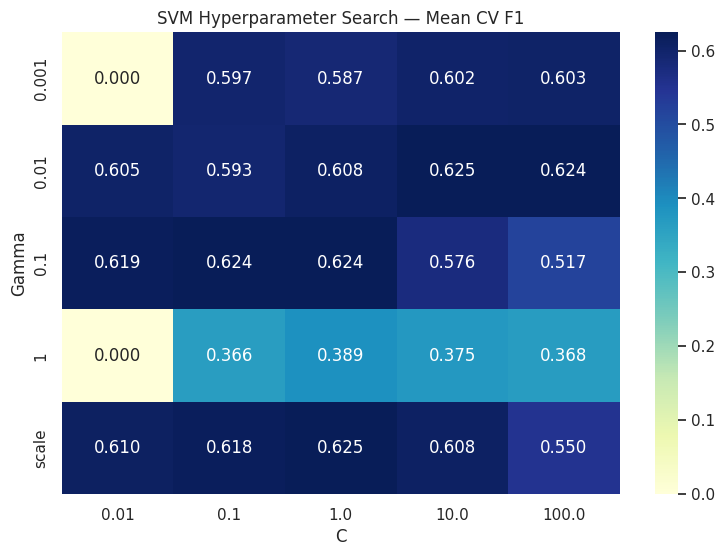

In [ ]:
svm_cv = pd.DataFrame(svm_search.cv_results_)
pivot = svm_cv.pivot_table(
    index="param_model__gamma",
    columns="param_model__C",
    values="mean_test_score",
    aggfunc="mean"
)

plt.figure(figsize=(9,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("SVM Hyperparameter Search — Mean CV F1")
plt.xlabel("C")
plt.ylabel("Gamma")
plt.show()

# 15. Evaluate tuned models on the untouched test set



The test set was **not used to choose hyperparameters**. Only now do we evaluate the best CV-selected models on it. This gives a cleaner estimate of generalization.

In [ ]:
tuned_searches = {
    "Tuned Logistic Regression": logistic_search,
    "Tuned Decision Tree": dt_search,
    "Tuned Random Forest": rf_search,
    "Tuned SVM": svm_search
}

tuned_results = []
tuned_fitted = {}

for name, search in tuned_searches.items():
    model = search.best_estimator_
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]
    tuned_fitted[name] = (model, pred, prob)
    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values("F1", ascending=False)
display(tuned_results_df)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,Tuned Random Forest,0.765791,0.540741,0.780749,0.638950,0.844218,0.657301
3,Tuned SVM,0.759404,0.532468,0.767380,0.628697,0.831163,0.611789
0,Tuned Logistic Regression,0.743080,0.510274,0.796791,0.622129,0.846007,0.656952
1,Tuned Decision Tree,0.745919,0.514035,0.783422,0.620763,0.816110,0.547218


# 16. Baseline vs tuned improvement

This table answers the central question: **did tuning actually improve the models?**

The improvement is calculated as:

`Tuned metric - Baseline metric`

A positive value means the metric increased. A negative value means it decreased.

In [ ]:
baseline_lookup = baseline_results_df.set_index("Model")

mapping = {
    "Tuned Logistic Regression": "Logistic Regression",
    "Tuned Decision Tree": "Decision Tree",
    "Tuned Random Forest": "Random Forest",
    "Tuned SVM": "SVM"
}

comparison_rows = []
for tuned_name, base_name in mapping.items():
    b = baseline_lookup.loc[base_name]
    t = tuned_results_df.set_index("Model").loc[tuned_name]
    row = {"Model": base_name}
    for metric in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]:
        row[f"Baseline {metric}"] = b[metric]
        row[f"Tuned {metric}"] = t[metric]
        row[f"Change {metric}"] = t[metric] - b[metric]
    comparison_rows.append(row)

improvement_df = pd.DataFrame(comparison_rows)
display(improvement_df.round(4))

,Model,Baseline Accuracy,Tuned Accuracy,Change Accuracy,Baseline Precision,Tuned Precision,Change Precision,Baseline Recall,Tuned Recall,Change Recall,Baseline F1,Tuned F1,Change F1,Baseline ROC-AUC,Tuned ROC-AUC,Change ROC-AUC,Baseline PR-AUC,Tuned PR-AUC,Change PR-AUC
0,Logistic Regression,0.7388,0.7431,0.0043,0.5051,0.5103,0.0052,0.7914,0.7968,0.0053,0.6167,0.6221,0.0055,0.8470,0.8460,-0.0010,0.6615,0.6570,-0.0046
1,Decision Tree,0.7317,0.7459,0.0142,0.4946,0.5140,0.0194,0.4893,0.7834,0.2941,0.4919,0.6208,0.1288,0.6548,0.8161,0.1613,0.3789,0.5472,0.1683
2,Random Forest,0.7807,0.7658,-0.0149,0.6148,0.5407,-0.0741,0.4652,0.7807,0.3155,0.5297,0.6389,0.1093,0.8214,0.8442,0.0228,0.6081,0.6573,0.0492
3,SVM,0.7651,0.7594,-0.0057,0.5406,0.5325,-0.0082,0.7647,0.7674,0.0027,0.6334,0.6287,-0.0047,0.8220,0.8312,0.0091,0.5838,0.6118,0.0280


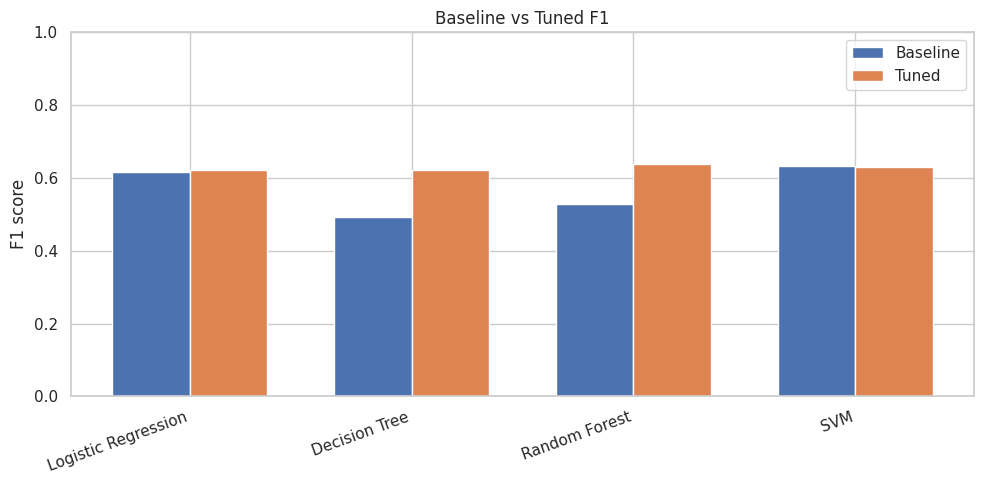

In [ ]:
# Visualize F1 improvement.
fig, ax = plt.subplots(figsize=(10,5))
labels = improvement_df["Model"]
x = np.arange(len(labels))
width = 0.35

ax.bar(x - width/2, improvement_df["Baseline F1"], width, label="Baseline")
ax.bar(x + width/2, improvement_df["Tuned F1"], width, label="Tuned")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1)
ax.set_title("Baseline vs Tuned F1")
ax.legend()
plt.tight_layout()
plt.show()

# 17. Cross-validation comparison of the final candidates

A single train/test split can be noisy. We therefore compare the strongest candidates using 5-fold stratified cross-validation on the training data.

In [ ]:
final_candidates = {
    "Tuned Logistic Regression": logistic_search.best_estimator_,
    "Tuned Decision Tree": dt_search.best_estimator_,
    "Tuned Random Forest": rf_search.best_estimator_,
    "Tuned SVM": svm_search.best_estimator_,
    "Baseline Gradient Boosting": baseline_models["Gradient Boosting"]
}

cv_rows = []
for name, model in final_candidates.items():
    scores = cross_validate(
        model, X_train, y_train,
        cv=CV,
        scoring={"accuracy":"accuracy", "precision":"precision", "recall":"recall", "f1":"f1", "roc_auc":"roc_auc", "pr_auc":"average_precision"},
        n_jobs=-1
    )
    cv_rows.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean(),
        "CV PR-AUC": scores["test_pr_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values("CV F1", ascending=False)
display(cv_results_df.round(4))

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,CV PR-AUC
2,Tuned Random Forest,0.7687,0.5455,0.7759,0.6404,0.8485,0.6648
0,Tuned Logistic Regression,0.7558,0.5262,0.7987,0.6343,0.8486,0.6665
3,Tuned SVM,0.7501,0.5201,0.7833,0.6247,0.8330,0.6225
1,Tuned Decision Tree,0.7464,0.5162,0.7759,0.6194,0.8169,0.5618
4,Baseline Gradient Boosting,0.8030,0.6653,0.5211,0.5842,0.8456,0.6623


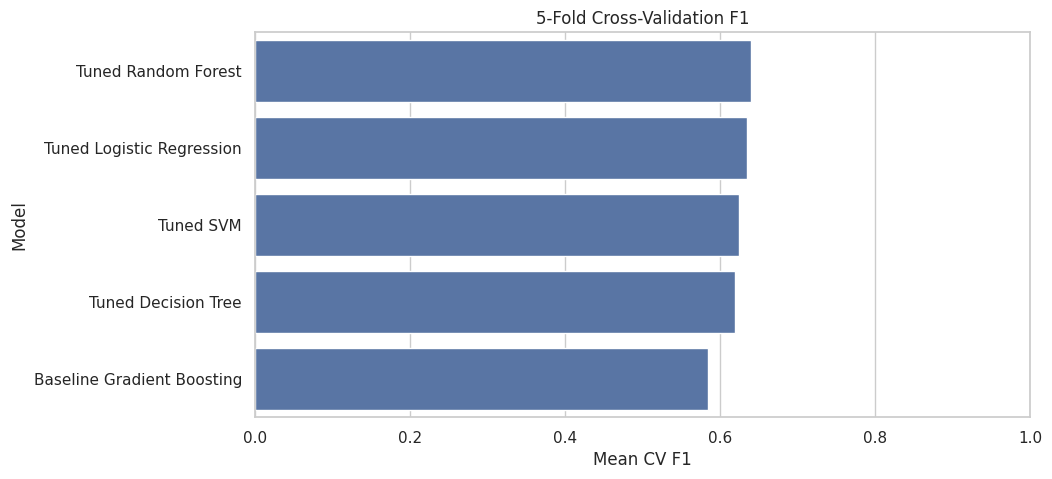

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=cv_results_df, x="CV F1", y="Model")
plt.xlim(0, 1)
plt.title("5-Fold Cross-Validation F1")
plt.xlabel("Mean CV F1")
plt.show()

# 18. Optional improvement — threshold tuning

Most classifiers use a default probability threshold of **0.50**. But churn detection is often a business trade-off between catching more churners (recall) and avoiding unnecessary interventions (precision).

We therefore inspect thresholds for the strongest tuned model and choose a threshold based on **F1 on the validation-style test set only for demonstration**.

> For a production project, the threshold should be selected on a validation set or through cross-validation, then evaluated once on the final untouched test set. Do not use the final test set to repeatedly optimize a deployed threshold.

In [ ]:
# Pick the model with the best CV F1.
best_model_name = cv_results_df.iloc[0]["Model"]
best_model = final_candidates[best_model_name]
best_model.fit(X_train, y_train)

probs = best_model.predict_proba(X_test)[:,1]
thresholds = np.linspace(0.10, 0.90, 81)
threshold_rows = []

for threshold in thresholds:
    pred = (probs >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_df.loc[threshold_df["f1"].idxmax()]
print("Model:", best_model_name)
print("Illustrative best F1 threshold on this evaluation split:", round(best_threshold_row["threshold"], 3))

Model: Tuned Random Forest
Illustrative best F1 threshold on this evaluation split: 0.5


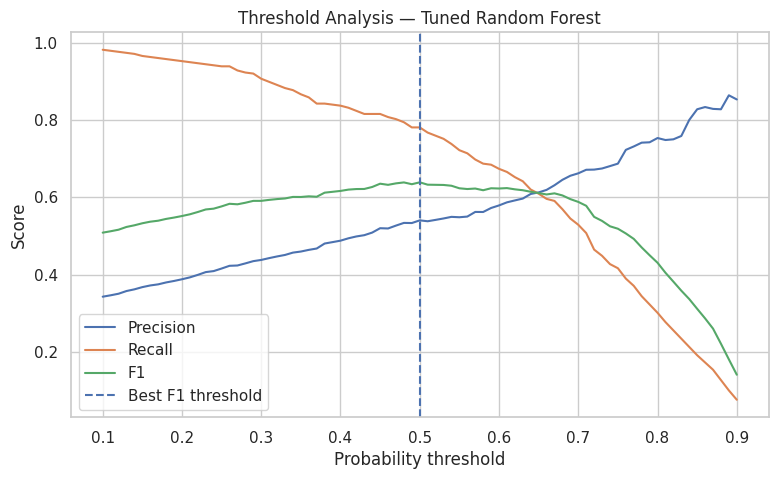

In [ ]:
plt.figure(figsize=(9,5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(best_threshold_row["threshold"], linestyle="--", label="Best F1 threshold")
plt.xlabel("Probability threshold")
plt.ylabel("Score")
plt.title(f"Threshold Analysis — {best_model_name}")
plt.legend()
plt.show()

# 19. Feature importance / model interpretation

For the final model, interpretation should use the fitted preprocessing pipeline rather than trying to interpret the raw dataframe directly.

For Logistic Regression we can inspect coefficients after one-hot encoding. For tree ensembles we can inspect feature importances. Here we show the Random Forest if it is the selected model; otherwise we show permutation importance for the selected pipeline.

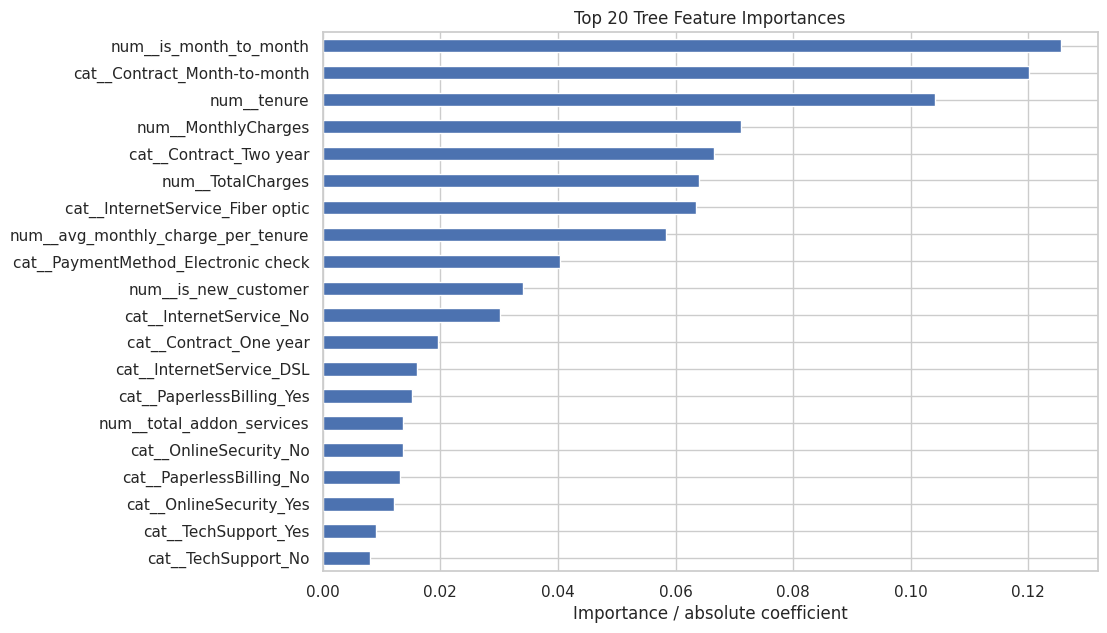

In [ ]:
# Fit the selected model on the training data.
best_model.fit(X_train, y_train)

# Try direct model coefficients/importances after preprocessing.
model_step = best_model.named_steps["model"]
preprocess_step = best_model.named_steps["preprocess"]

feature_names = preprocess_step.get_feature_names_out()

if hasattr(model_step, "feature_importances_"):
    importance = pd.Series(
        model_step.feature_importances_, index=feature_names
    ).sort_values(ascending=False).head(20)
    title = "Top 20 Tree Feature Importances"
elif hasattr(model_step, "coef_"):
    importance = pd.Series(
        np.abs(model_step.coef_[0]), index=feature_names
    ).sort_values(ascending=False).head(20)
    title = "Top 20 Absolute Logistic Regression Coefficients"
else:
    importance = None

if importance is not None:
    plt.figure(figsize=(10,7))
    importance.sort_values().plot(kind="barh")
    plt.title(title)
    plt.xlabel("Importance / absolute coefficient")
    plt.show()

# 20. Final model evaluation

The final report should contain the test-set metrics for the selected candidate. Remember that the model was selected using cross-validation on the training data; the test set is used only for final evaluation in a clean experiment.

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned Random Forest,0.7658,0.5407,0.7807,0.6389,0.8442,0.6573


              precision    recall  f1-score   support

    No Churn       0.91      0.76      0.83      1035
       Churn       0.54      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



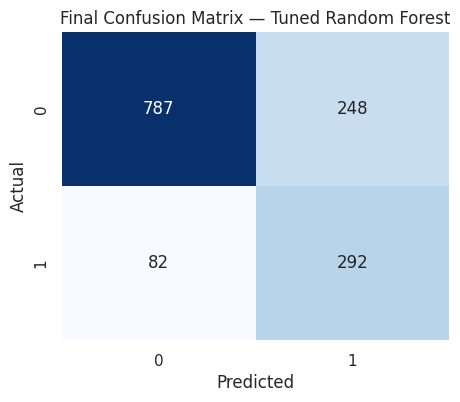

In [ ]:
best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:,1]

final_metrics = pd.DataFrame([{
    "Model": best_model_name,
    "Accuracy": accuracy_score(y_test, best_pred),
    "Precision": precision_score(y_test, best_pred, zero_division=0),
    "Recall": recall_score(y_test, best_pred, zero_division=0),
    "F1": f1_score(y_test, best_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, best_prob),
    "PR-AUC": average_precision_score(y_test, best_prob)
}])

display(final_metrics.round(4))

print(classification_report(
    y_test, best_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Final Confusion Matrix — {best_model_name}")
plt.show()

# 21. Save the final model

Saving the complete pipeline is safer than saving only the classifier because the pipeline contains the preprocessing steps needed to transform future customer records in exactly the same way.

In [ ]:
import joblib

MODEL_PATH = "telco_churn_final_pipeline.joblib"
joblib.dump(best_model, MODEL_PATH)
print("Saved:", MODEL_PATH)

# 22. Example prediction workflow

A future customer should be supplied using the **same raw feature names** as the training data. The saved pipeline performs preprocessing automatically.

In [ ]:
# Example only — replace values with a real customer.
example_customer = X_test.iloc[[0]].copy()
example_prediction = best_model.predict(example_customer)[0]
example_probability = best_model.predict_proba(example_customer)[0, 1]

print("Predicted churn:", "Yes" if example_prediction == 1 else "No")
print("Predicted churn probability:", round(example_probability, 4))

Predicted churn: No
Predicted churn probability: 0.0381


# 23. Final project conclusions

## What was corrected
1. `customerID` was removed as an identifier.
2. `TotalCharges` was converted safely to numeric and its blank values were handled explicitly.
3. Nominal categorical variables are one-hot encoded instead of assigning artificial ordinal numbers.
4. Scaling is performed inside pipelines and is fitted only on training folds.
5. The test set is not used during hyperparameter selection.
6. Duplicate scaling steps from the original notebook were removed.
7. Evaluation was expanded beyond accuracy.
8. Model complexity is controlled through hyperparameter tuning.
9. Feature engineering is measured rather than assumed to help.
10. Threshold analysis is treated as a separate decision layer rather than changing the classifier itself.

## What you should learn from the project
- **Preprocessing:** why `ColumnTransformer` and `Pipeline` prevent leakage.
- **Encoding:** why one-hot encoding is safer for nominal categories.
- **Imbalance:** why recall, F1 and PR-AUC matter for churn.
- **Regularization:** how Logistic Regression's `C` changes model complexity.
- **Trees:** how depth and leaf size affect overfitting.
- **Random Forest:** how ensembles reduce variance and how hyperparameters affect complexity.
- **SVM:** how `C` and `gamma` control the decision boundary.
- **Cross-validation:** why a single split is not enough for model selection.
- **Hyperparameter tuning:** how to search systematically rather than guessing.
- **Thresholds:** how the business objective can change the precision/recall trade-off.
- **Interpretability:** how to connect model behavior back to customer features.

## Important limitation
This dataset is observational. Model associations should not be interpreted as proof that a business intervention will cause churn to decrease. A predictive model estimates risk; it does not establish causal effects.

# 24. Quick revision notes

### `C` in Logistic Regression / SVM
`C` is the inverse of regularization strength.

- small `C` → stronger regularization → simpler model
- large `C` → weaker regularization → model can fit training data more closely

### Precision
Of the customers predicted as churners, how many actually churned?

$$Precision = \frac{TP}{TP+FP}$$

### Recall
Of the customers who actually churned, how many did we detect?

$$Recall = \frac{TP}{TP+FN}$$

### F1
Harmonic mean of precision and recall.

$$F1 = 2\frac{Precision\times Recall}{Precision+Recall}$$

### ROC-AUC
Measures how well the model ranks positive cases above negative cases across thresholds.

### PR-AUC
Summarizes the precision/recall trade-off and is often useful for an imbalanced positive class such as churn.

### Data leakage
Never fit preprocessing, feature selection, PCA, SMOTE, or hyperparameter search using the final test set.

### Final workflow

`Raw data → cleaning → feature engineering → train/test split → preprocessing pipeline → baseline models → cross-validation → tuning → final test evaluation → interpretation → save pipeline`